In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_community.tools import DuckDuckGoSearchRun

###
TOOLS

In [7]:
# Duck Duck Go

search_engine = DuckDuckGoSearchRun()

# Calculator 

@tool
def calculator(a:float,b:float,c:str):
    """Perform Based Operation on two numbers"""

    if c=='add':
        return a + b
    elif c=='subtract':
        return a-b
    elif c=='multiply':
        return a*b
    elif c=='divide':
        return a/b
    else:
        raise ValueError("Invalid operation")

tookkit = [search_engine,calculator]


In [8]:
llm = ChatOpenAI(model_name="gpt-5-mini")


agent = create_agent(model=llm,tools=tookkit)



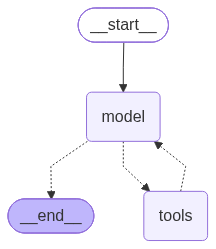

In [10]:
agent

In [13]:
response = agent.invoke({'messages':[{'role':'user','content':'tell me what is the temperature in nihal vihar nangloi'}]})

In [14]:
print(response["messages"][-1].content)

Do you mean the current temperature right now? I can look it up and give you the live value — would you like me to fetch it? 

If you prefer an estimate instead of a live lookup: Nihal Vihar (Nangloi, West Delhi) in mid‑August is typically around 30–38°C during the day.


In [ ]:
response.model

{'messages': [HumanMessage(content='tell me what is the temperature in nihal vihar nangloi', additional_kwargs={}, response_metadata={}, id='c013451c-77da-402c-93d5-32d6ddeb433b'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 196, 'total_tokens': 295, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EDqqL6jTPUioEV4L4cOBin1vA1zgK', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a00fb7-d74a-7593-b4a0-3270b909a30d-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Nihal Vihar Nangloi temperature current'}, 'id': 'call_z8Ue8QmYgvxJHGmpP0pdIXJS', 'typ